# **Fine Grain Lex Flex with TFIDF**

This is a comparative Term Frequency-Inverse Document Frequency (TFIDF) analysis of six translations spanning roughly the last century: 1919–2018. 

Strightforward as I can, I'll compute TFIDF, hypothesis testing, and then plot some heatmaps.

In [1]:
# ----------------------------------------------------------------------
# Baic Libraries
# ----------------------------------------------------------------------
import sys
import os

import ast
from collections import Counter

import re
import nltk

import numpy as np
import pandas as pd

import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

import scipy.stats as stats
from itertools import combinations

In [2]:
# ----------------------------------------------------------------------
# Visualization
# ----------------------------------------------------------------------

sys.path.append('/Users/debr/English-Homer/functions') 
import matplotlib.pyplot as plt
import seaborn as sns

import e_chroma as chroma # My Vizualization library
import e_plots as oz      # My custom plots library
import e_pandisplay as pan# My pandas display options

import e_nlp_ody as e     # Import my nlp functions

import warnings           # Nononsense provision
warnings.filterwarnings('ignore')


* Got some chroma in your soma, Oma!
	 »----> use chroma.save_figure(fig, 'my_plot')
Default output path: ./Homer_xplots/

* OZ is behind the curtain!
	 »----> use oz.<func>
	 »----> also, oz goes chroma (for styling)!

* Pan is taking over
	 »----> use pan.<func>
✓ Pandas display reset to pandisplay defaults

* The editor is in the house!
	 »----> use e.<func> e.g. nlp = e.NLPPipeline(language='english')

Stopwords customized:
  Added: {'ten', 'five', 'seven', 'two', 'four', "'and", 'n', 'eight', 'six', 'nine', 'three', "'", 'one'}
  Removed: {''}
  Total stopwords: 211
Punctuation customized:
  Keeping: {'', '-'}
  Additional removals: {'-', '…', '\\', ',\n        "\'",\n        ', "'", '—'}
  Punctuation to be removed: !"#$%&'()*+,,
        "'",
        -./:;<=>?@[\]^_`{|}~—…


[nltk_data] Downloading package punkt_tab to /Users/debr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
# ----------------------------------------------------------------------
# File management
# ----------------------------------------------------------------------

# TO UPDATE
nb_id = "TFIDF_Six_Mo-03_31_25"
output_path = f"./{nb_id}/"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
output_path_plots = f"./{output_path}/{nb_id}_plots/"
os.makedirs(os.path.dirname(output_path_plots), exist_ok=True)
#chroma.set_output_path(output_path_plots)

In [4]:
# ----------------------------------------------------------------------
# Odysseys
# ----------------------------------------------------------------------

translators = ['AT_Murray', 'Fitzgerald', 'Lattimore', 'Fagles', 'Wilson', 'Green']

dfs = []

for odyssey in translators:
    filepath = f"/Users/debr/odysseys_en/dataframed/Odyssey_{odyssey}_DataFrame.csv"
    temp_df = pd.read_csv(filepath)  
    dfs.append(temp_df)  # Append it to the list

df = pd.concat(dfs, axis=0, ignore_index=True)

df["text"] = df["text"].apply(ast.literal_eval)
df["tokens"] = df["tokens"].apply(ast.literal_eval)
df['translator'] = pd.Categorical(df['author'])
df["book_num"] = pd.Categorical(df["book_num"])
odysseys_df = df[['translator', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens']]
e.check_df(odysseys_df)

Mr righteous here has no missing values!

* df columns: Index(['translator', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens'], dtype='object') 

* Shape: (144, 6) 

* Total memory in MB: 3.490719


In [5]:
def calculate_tfidf(df):
    """
    Calculate TF-IDF scores for a DataFrame with book_id and tokens columns.
    
    Parameters:
    -----------
    df : pandas DataFrame
        A DataFrame with 'book_id' and 'tokens' columns. 
        The 'tokens' column should contain lists of tokens (as strings or actual lists).
    
    Returns:
    --------
    pandas DataFrame
        The original DataFrame with additional columns:
        - term_freq: Dictionary of term frequencies for each token
        - term_counts: Dictionary of raw counts for each token
        - idf: Dictionary of IDF scores for each token
        - tf_idf: Dictionary of TF-IDF scores for each token
    """
    # Create a copy of the DataFrame to avoid modifying the original
    result_df = df.copy()
    
    # Function to compute term frequency and term counts
    def term_freq_by_doc(list_of_tokens):
        # Handle both string representation of list and actual list
        if isinstance(list_of_tokens, str):
            token_list = eval(list_of_tokens)  # Convert string representation to list
        else:
            token_list = list_of_tokens  # Use as is if already a list
        
        # Count occurrences of each term
        term_counts = Counter(token_list)
        
        # Total number of terms in the document
        total_terms = len(token_list)
        
        # Compute TF: term frequency for each token
        term_freq = {term: count / total_terms for term, count in term_counts.items()}
        
        return term_freq, term_counts
    
    # Apply function to compute TF for each book
    result_df["term_freq"], result_df["term_counts"] = zip(*result_df["tokens"].apply(term_freq_by_doc))
    
    # Get total number of documents (books)
    N = len(result_df)
    
    # Count how many documents contain each term
    doc_containing_term = Counter()
    for term_counts in result_df["term_freq"]:
        doc_containing_term.update(term_counts.keys())  # Count unique terms in each document
    
    # Compute IDF for each term
    idf_scores = {term: np.log(N / (1 + doc_count)) for term, doc_count in doc_containing_term.items()}  # Adding 1 to avoid division by zero
    
    # Add IDF column to df
    result_df["idf"] = result_df["term_freq"].apply(lambda term_freq: {term: idf_scores[term] for term in term_freq})
    
    # Compute TF-IDF by multiplying TF and IDF for each term in each document
    result_df["tf_idf"] = result_df.apply(lambda row: {term: row["term_freq"][term] * row["idf"][term] for term in row["term_freq"]}, axis=1)
    
    return result_df

In [6]:
tfidf_df = calculate_tfidf(odysseys_df)
tfidf_df.head(2)

,translator,book_num,text,tokens,num_words,num_tokens,term_freq,term_counts,idf,tf_idf
0,AT_Murray,1,"[Tell me, O Muse, of that many-sided hero who\n, traveled far and wide after he had sacked the famous town of Troy . Many cities did he visit, and many were\n, the people with whose customs and th...","[tell, muse, manysided, hero, traveled, far, wide, sacked, famous, town, troy, many, cities, visit, many, people, whose, customs, thinking, acquainted, many, things, suffered, sea, seeking, save, ...",4187,1800,"{'tell': 0.009444444444444445, 'muse': 0.0005555555555555556, 'manysided': 0.0005555555555555556, 'hero': 0.0005555555555555556, 'traveled': 0.0005555555555555556, 'far': 0.0011111111111111111, 'w...","{'tell': 17, 'muse': 1, 'manysided': 1, 'hero': 1, 'traveled': 1, 'far': 2, 'wide': 1, 'sacked': 1, 'famous': 1, 'town': 4, 'troy': 6, 'many': 10, 'cities': 1, 'visit': 2, 'people': 7, 'whose': 3,...","{'tell': -0.006920442844573795, 'muse': 2.1972245773362196, 'manysided': 4.276666119016055, 'hero': 0.6793538584276094, 'traveled': 1.5686159179138452, 'far': 0.03533936644530886, 'wide': 0.481176...","{'tell': -6.535973797653029e-05, 'muse': 0.0012206803207423442, 'manysided': 0.002375925621675586, 'hero': 0.00037741881023756077, 'traveled': 0.000871453287729914, 'far': 3.926596271700985e-05, '..."
1,AT_Murray,2,"[Now when the child of morning, rosy-fingered\n, Dawn, appeared, Telemakhos rose and dressed himself. He bound his sandals on to\n, his comely feet, girded his sword about his shoulder, and left h...","[child, morning, rosyfingered, dawn, appeared, telemakhos, rose, dressed, bound, sandals, comely, feet, girded, sword, shoulder, left, room, looking, like, immortal, god, sent, criers, round, call...",4245,1816,"{'child': 0.0011013215859030838, 'morning': 0.0005506607929515419, 'rosyfingered': 0.0005506607929515419, 'dawn': 0.0011013215859030838, 'appeared': 0.0005506607929515419, 'telemakhos': 0.01486784...","{'child': 2, 'morning': 1, 'rosyfingered': 1, 'dawn': 2, 'appeared': 1, 'telemakhos': 27, 'rose': 3, 'dressed': 1, 'bound': 1, 'sandals': 1, 'comely': 1, 'feet': 1, 'girded': 1, 'sword': 1, 'shoul...","{'child': 0.2602830982636665, 'morning': 0.665748206371831, 'rosyfingered': 1.6025174695895266, 'dawn': 0.11000089521432849, 'appeared': 0.7651206801850345, 'telemakhos': 1.3588953869317761, 'rose...","{'child': 0.0002866553945635094, 'morning': 0.0003666014352267792, 'rosyfingered': 0.0008824435405228671, 'dawn': 0.0001211463603682032, 'appeared': 0.0004213219604543142, 'telemakhos': 0.02020384..."


In [7]:
e.check_df(tfidf_df)

Mr righteous here has no missing values!

* df columns: Index(['translator', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens', 'term_freq', 'term_counts', 'idf', 'tf_idf'], dtype='object') 

* Shape: (144, 10) 

* Total memory in MB: 20.775583


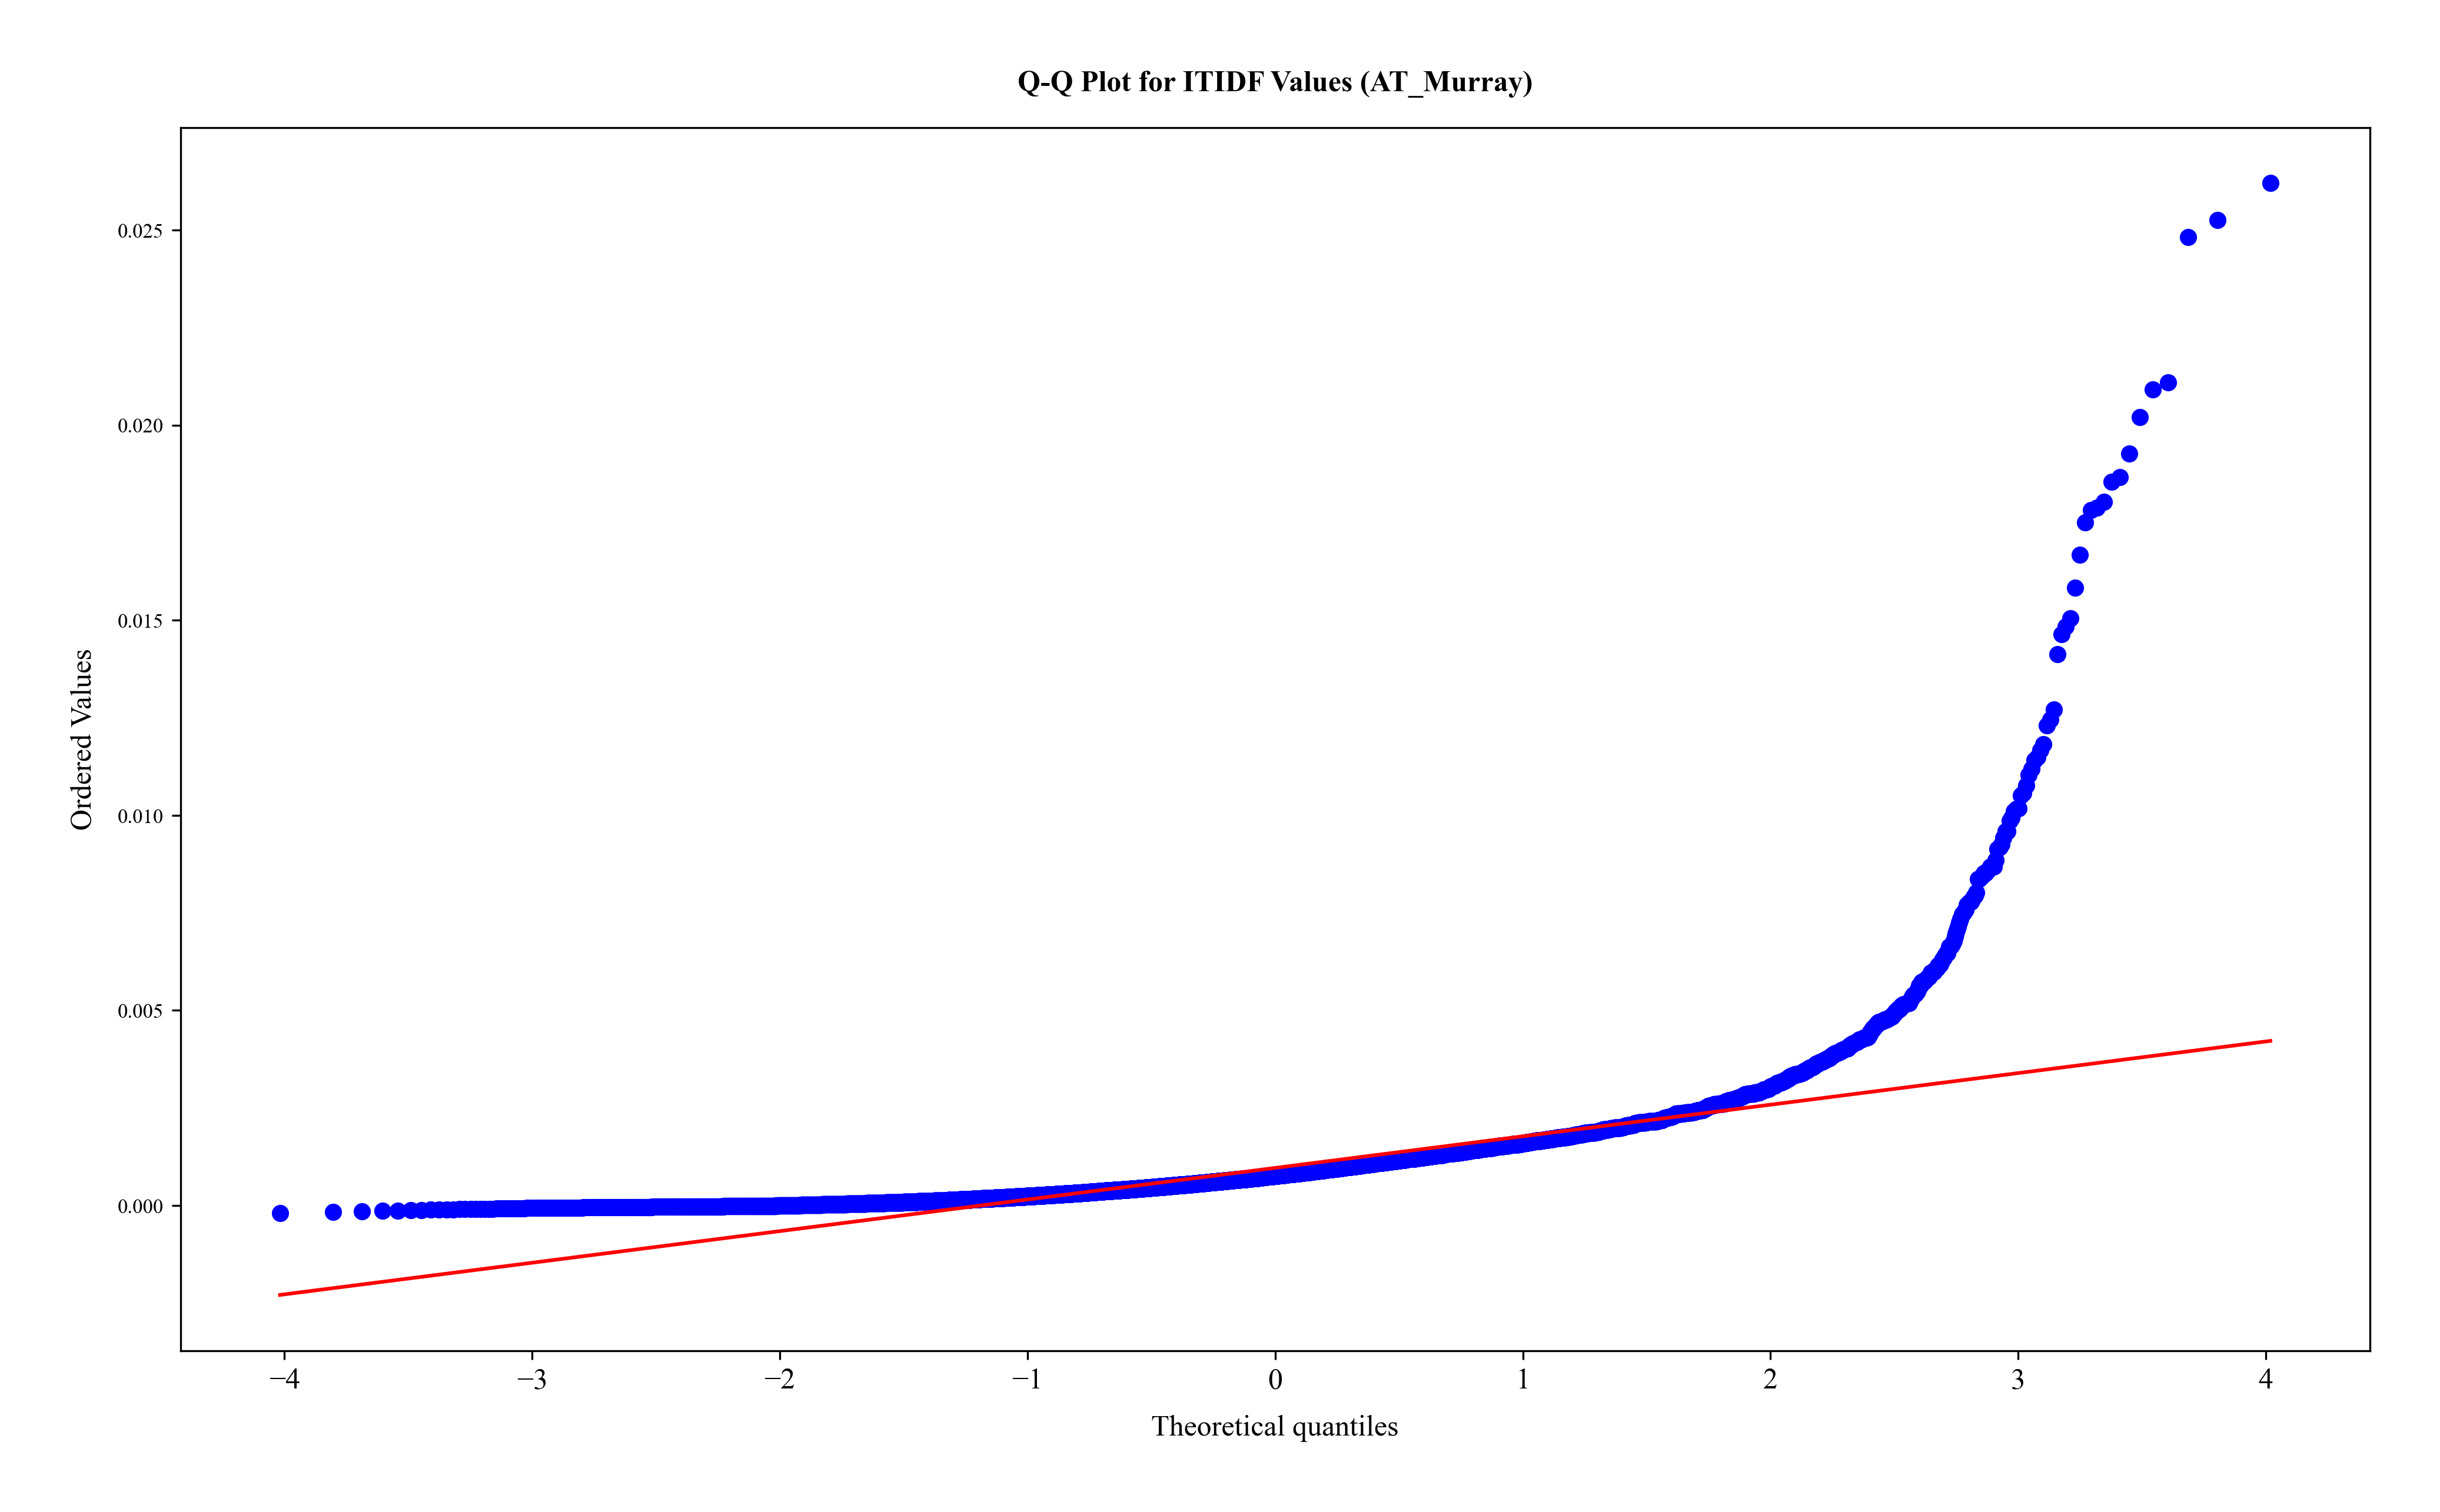

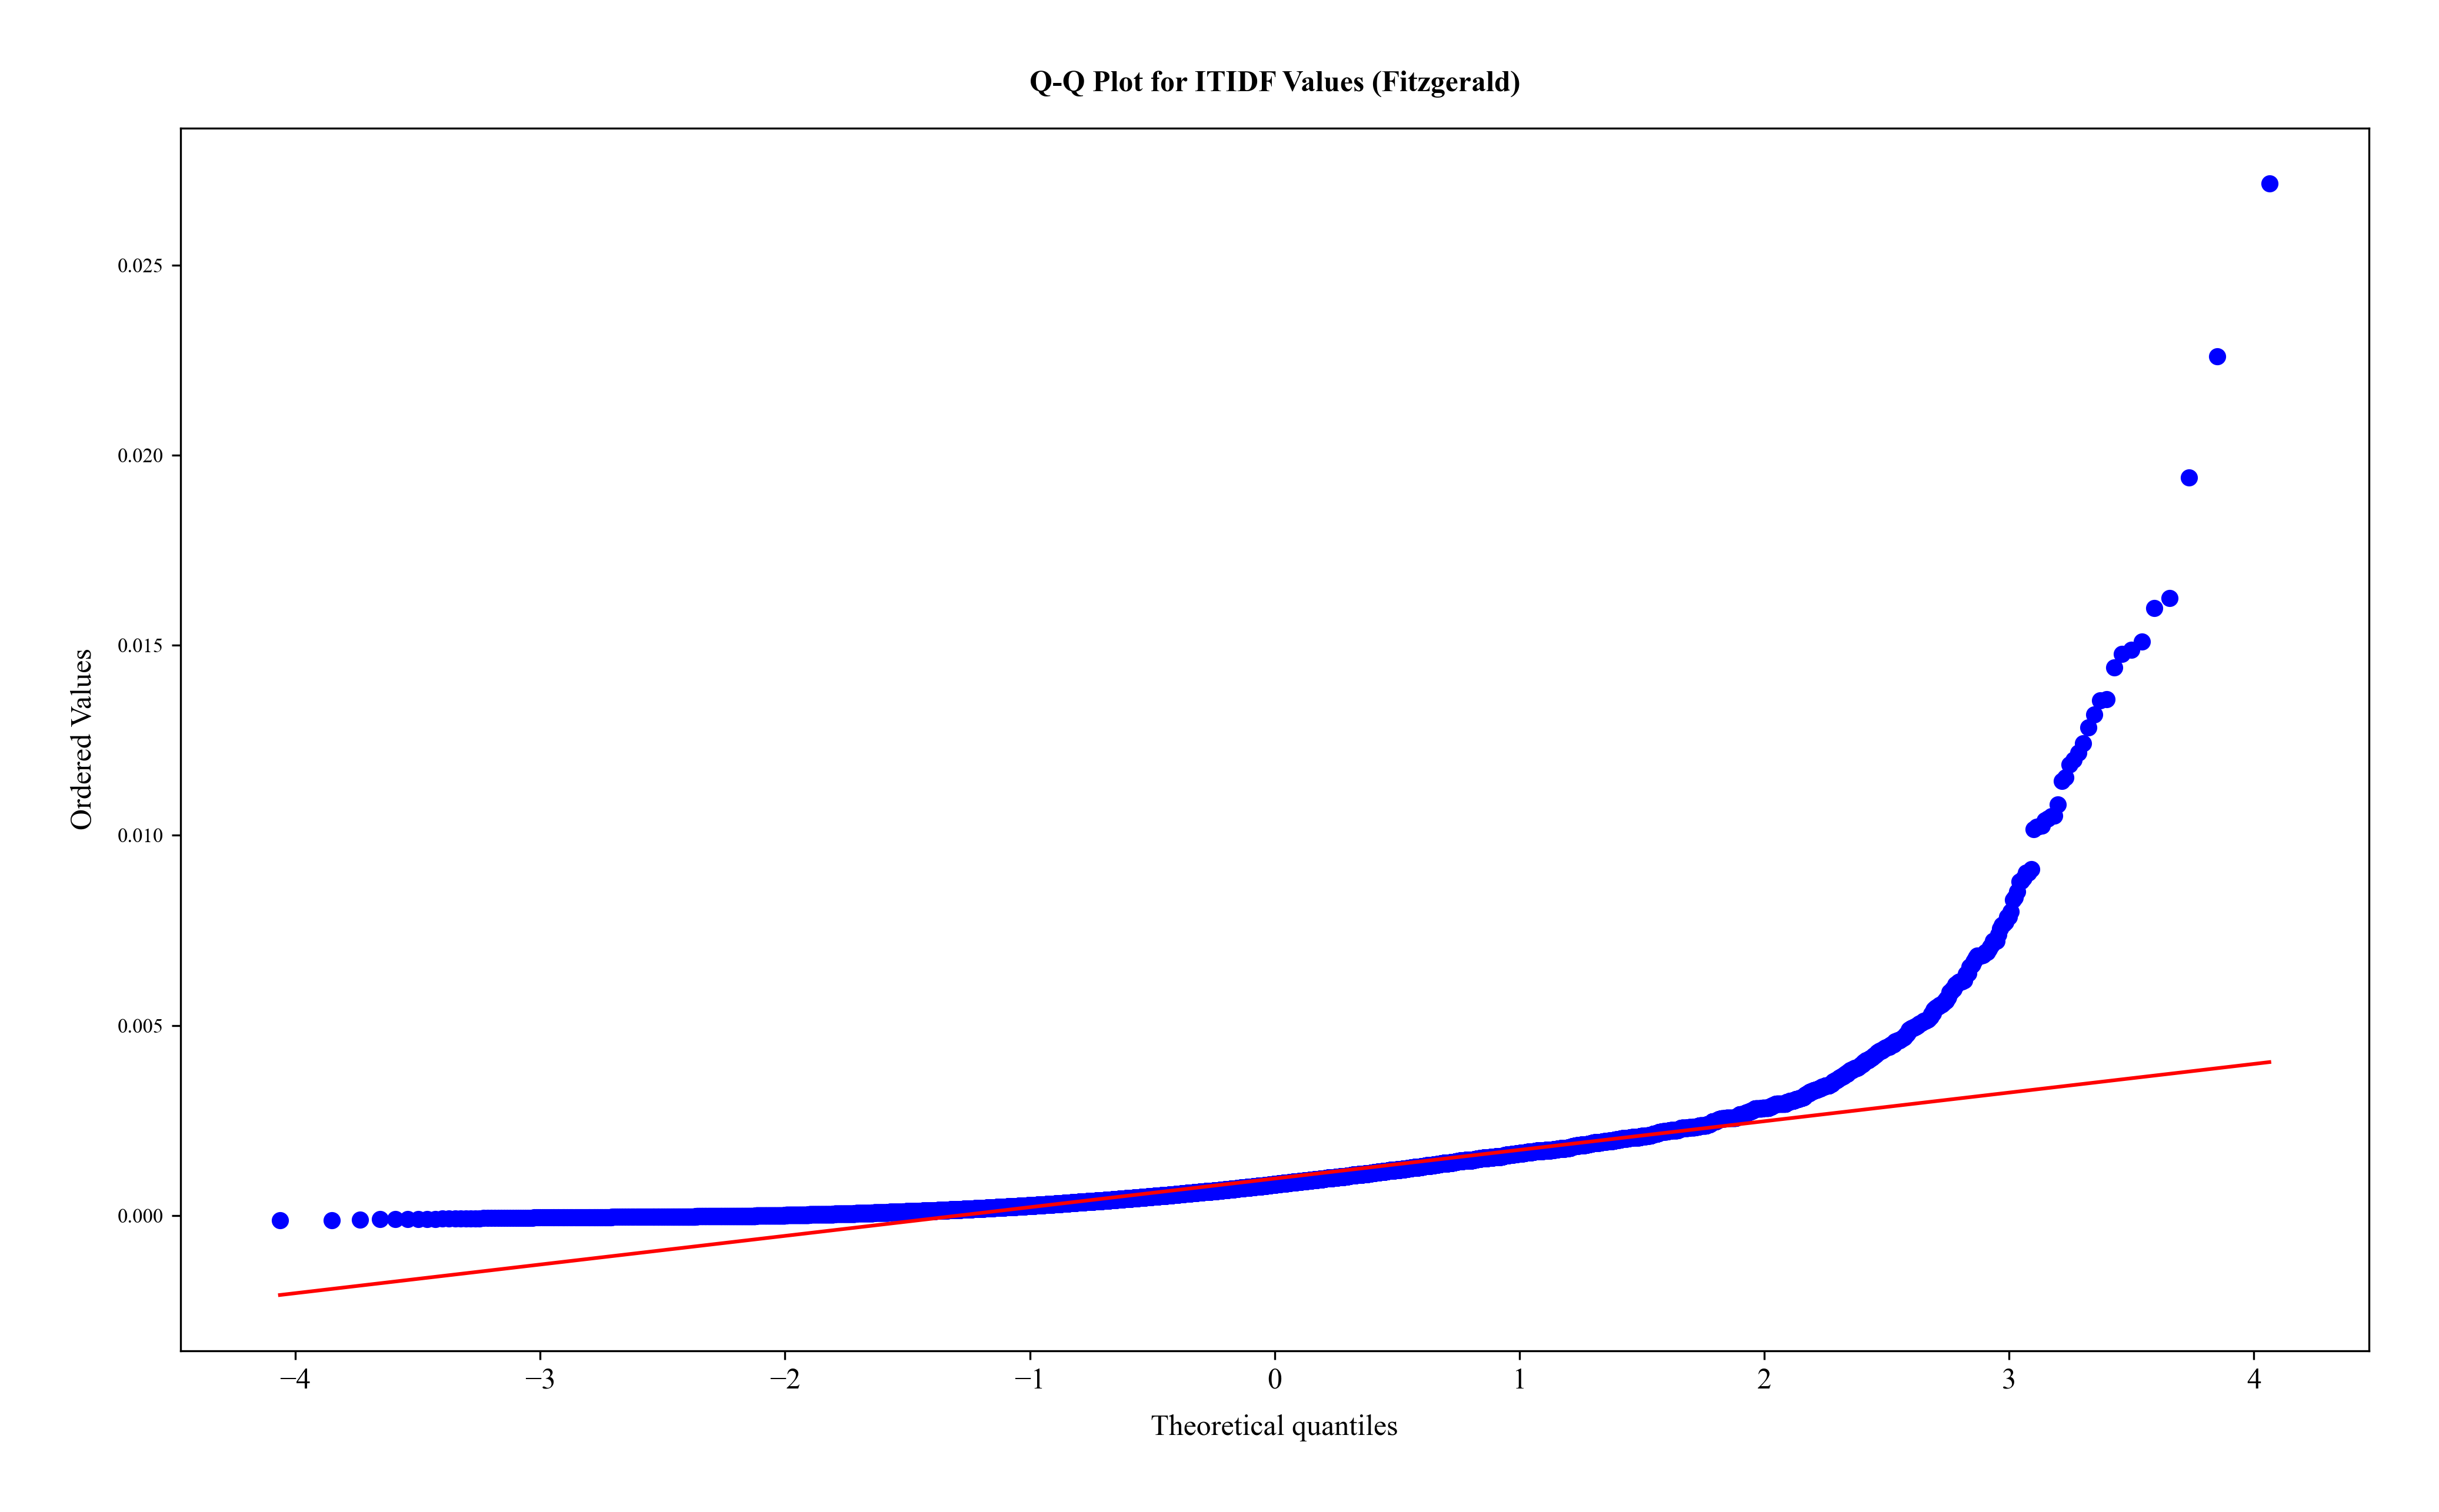

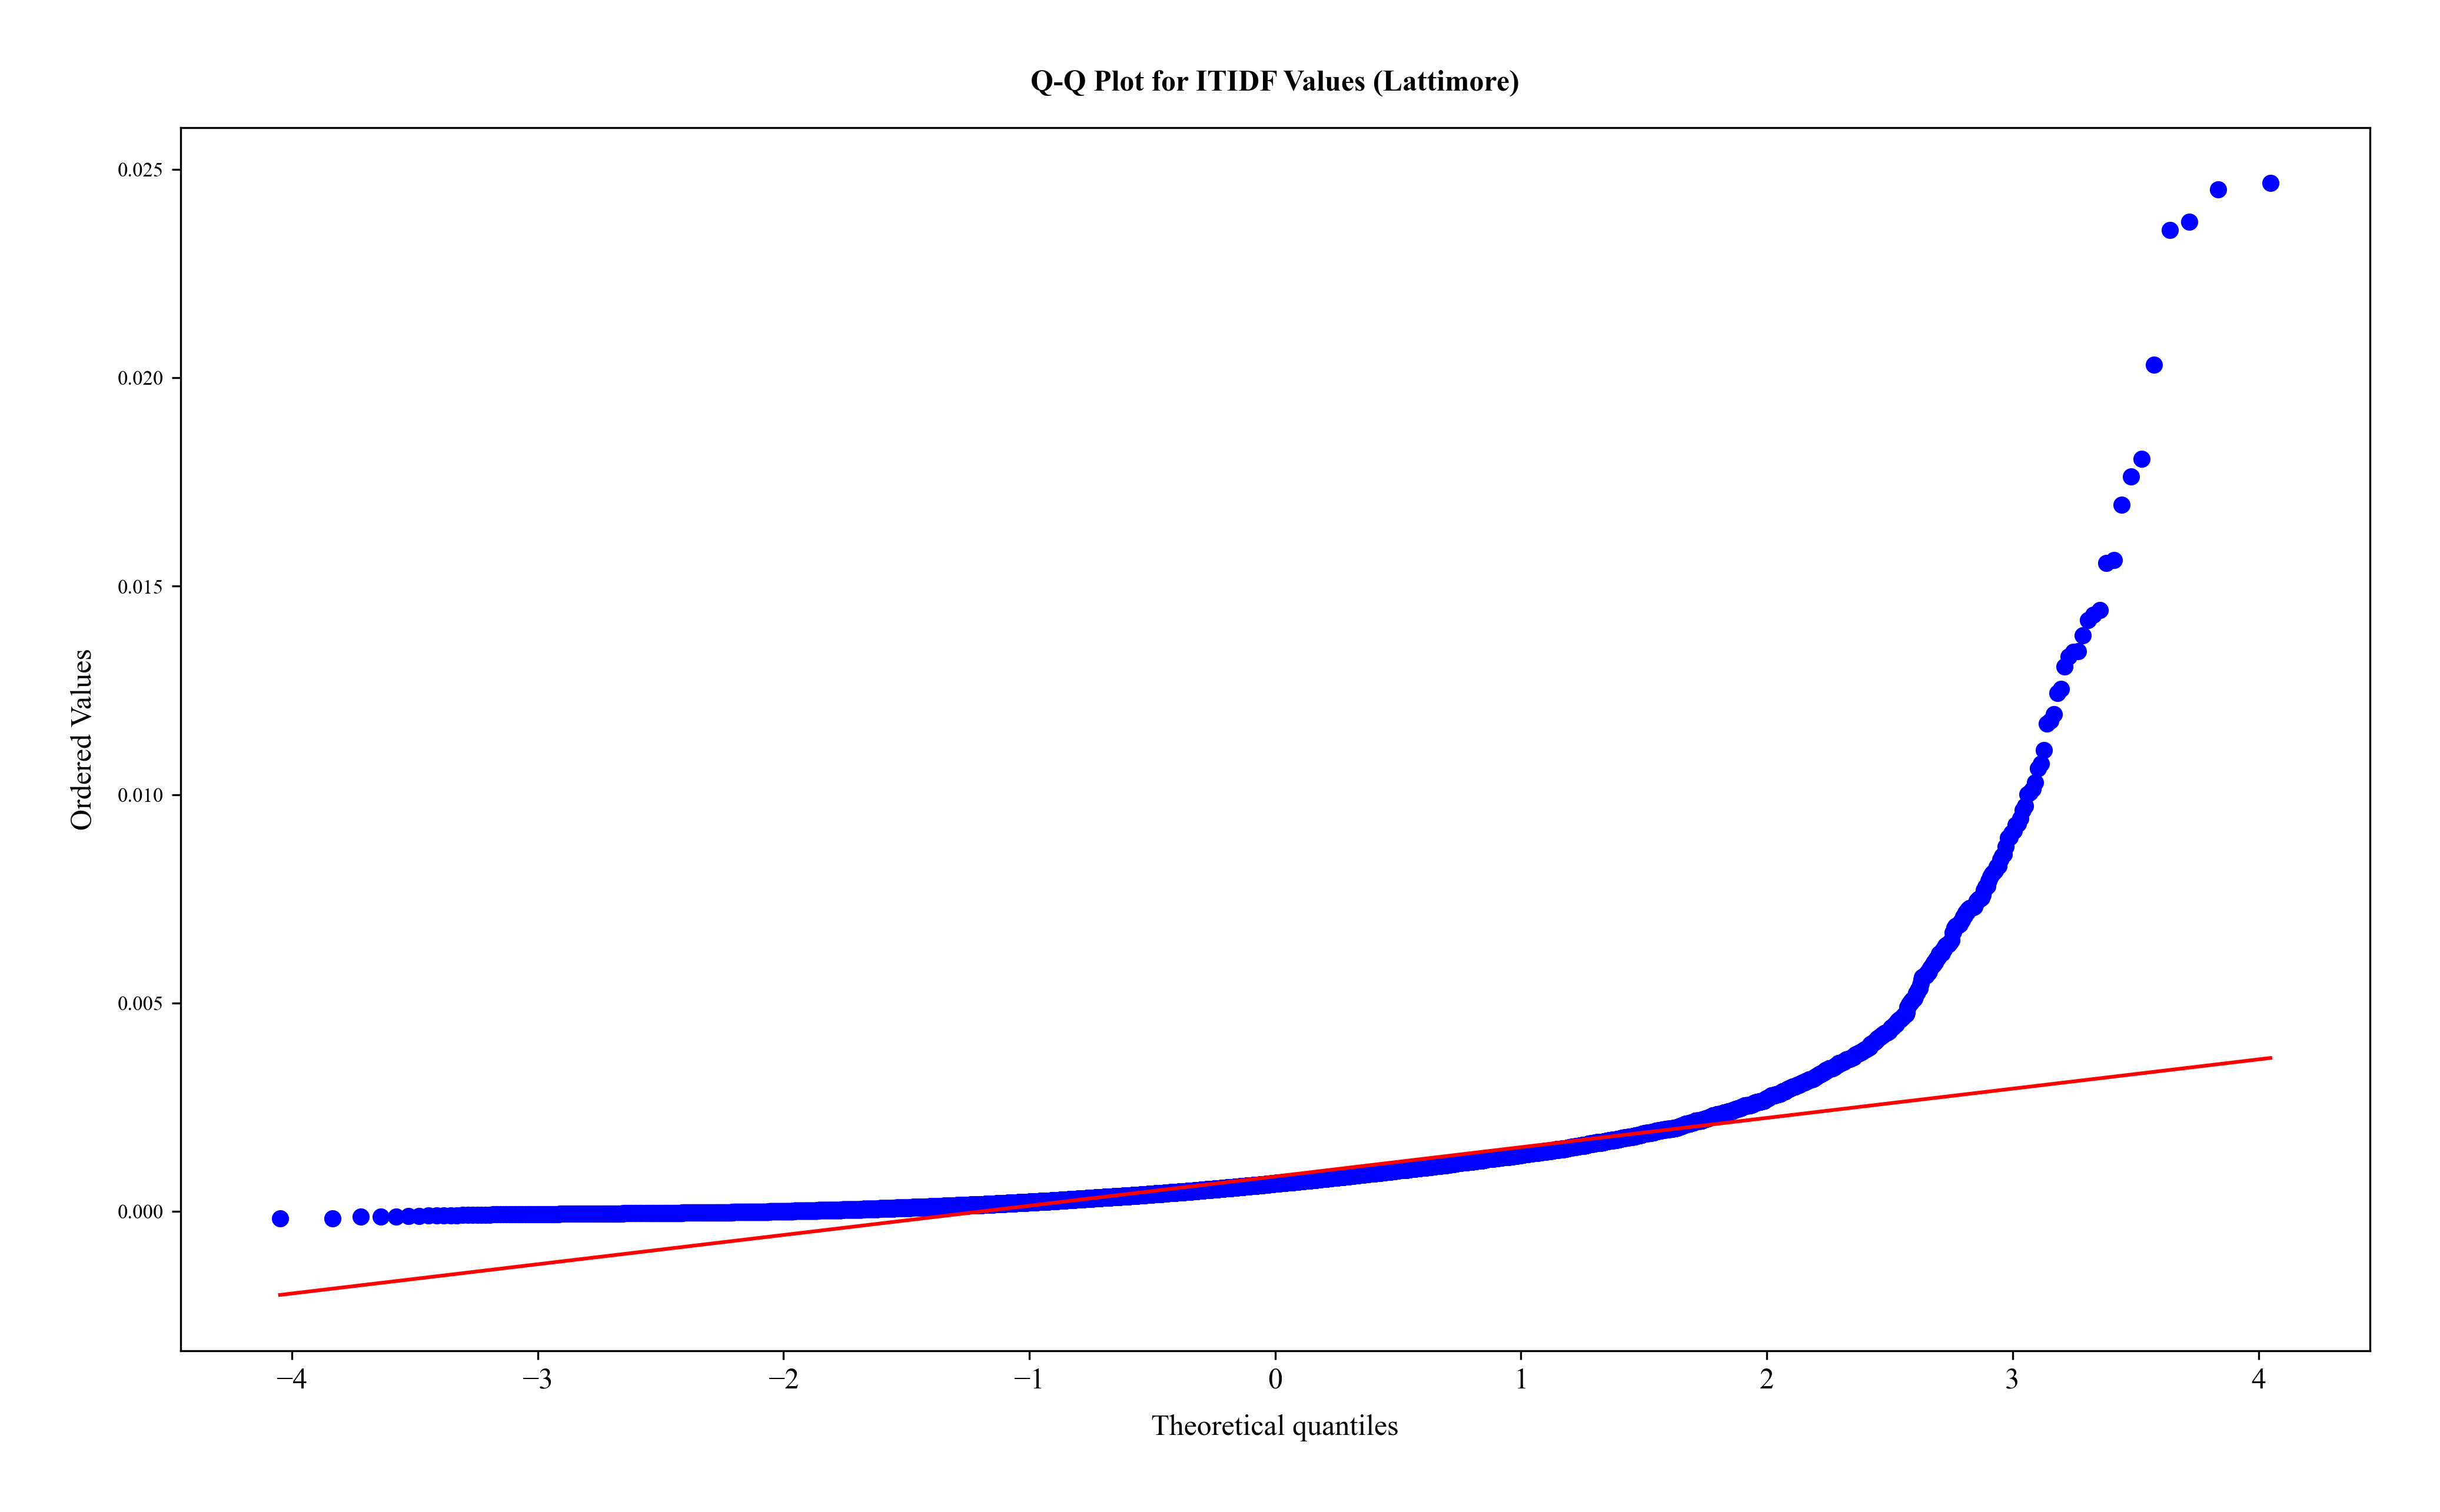

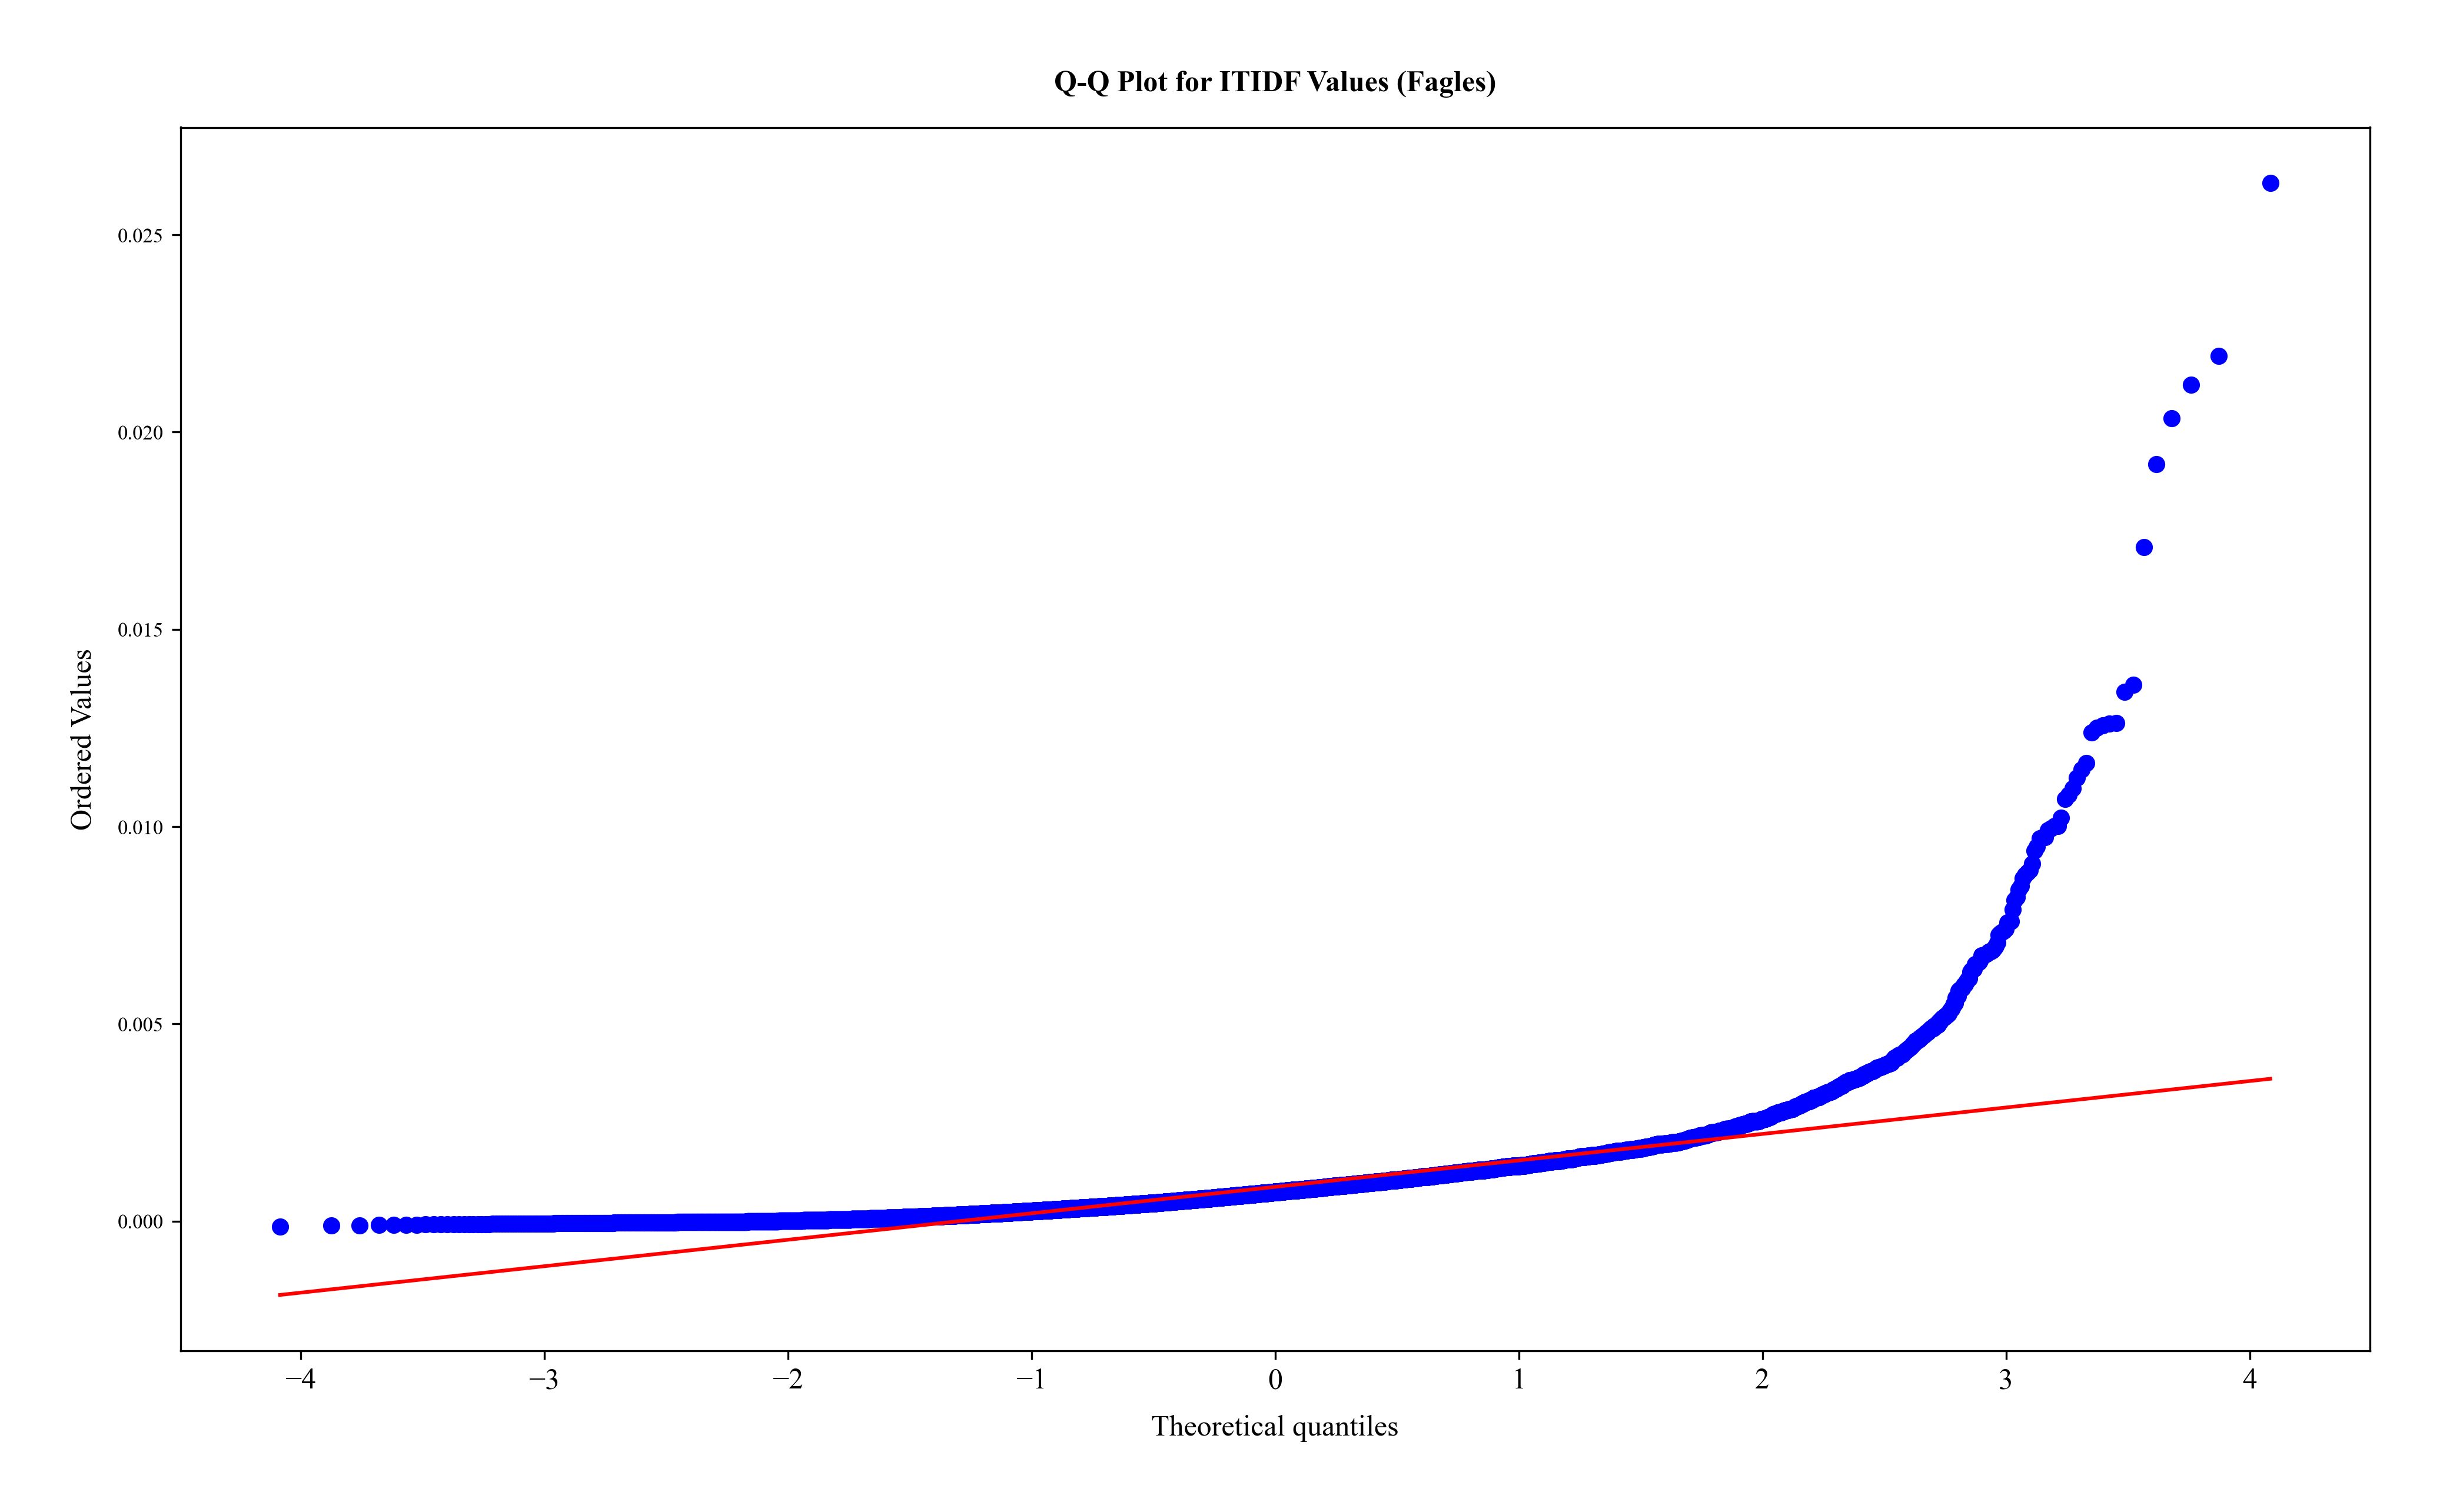

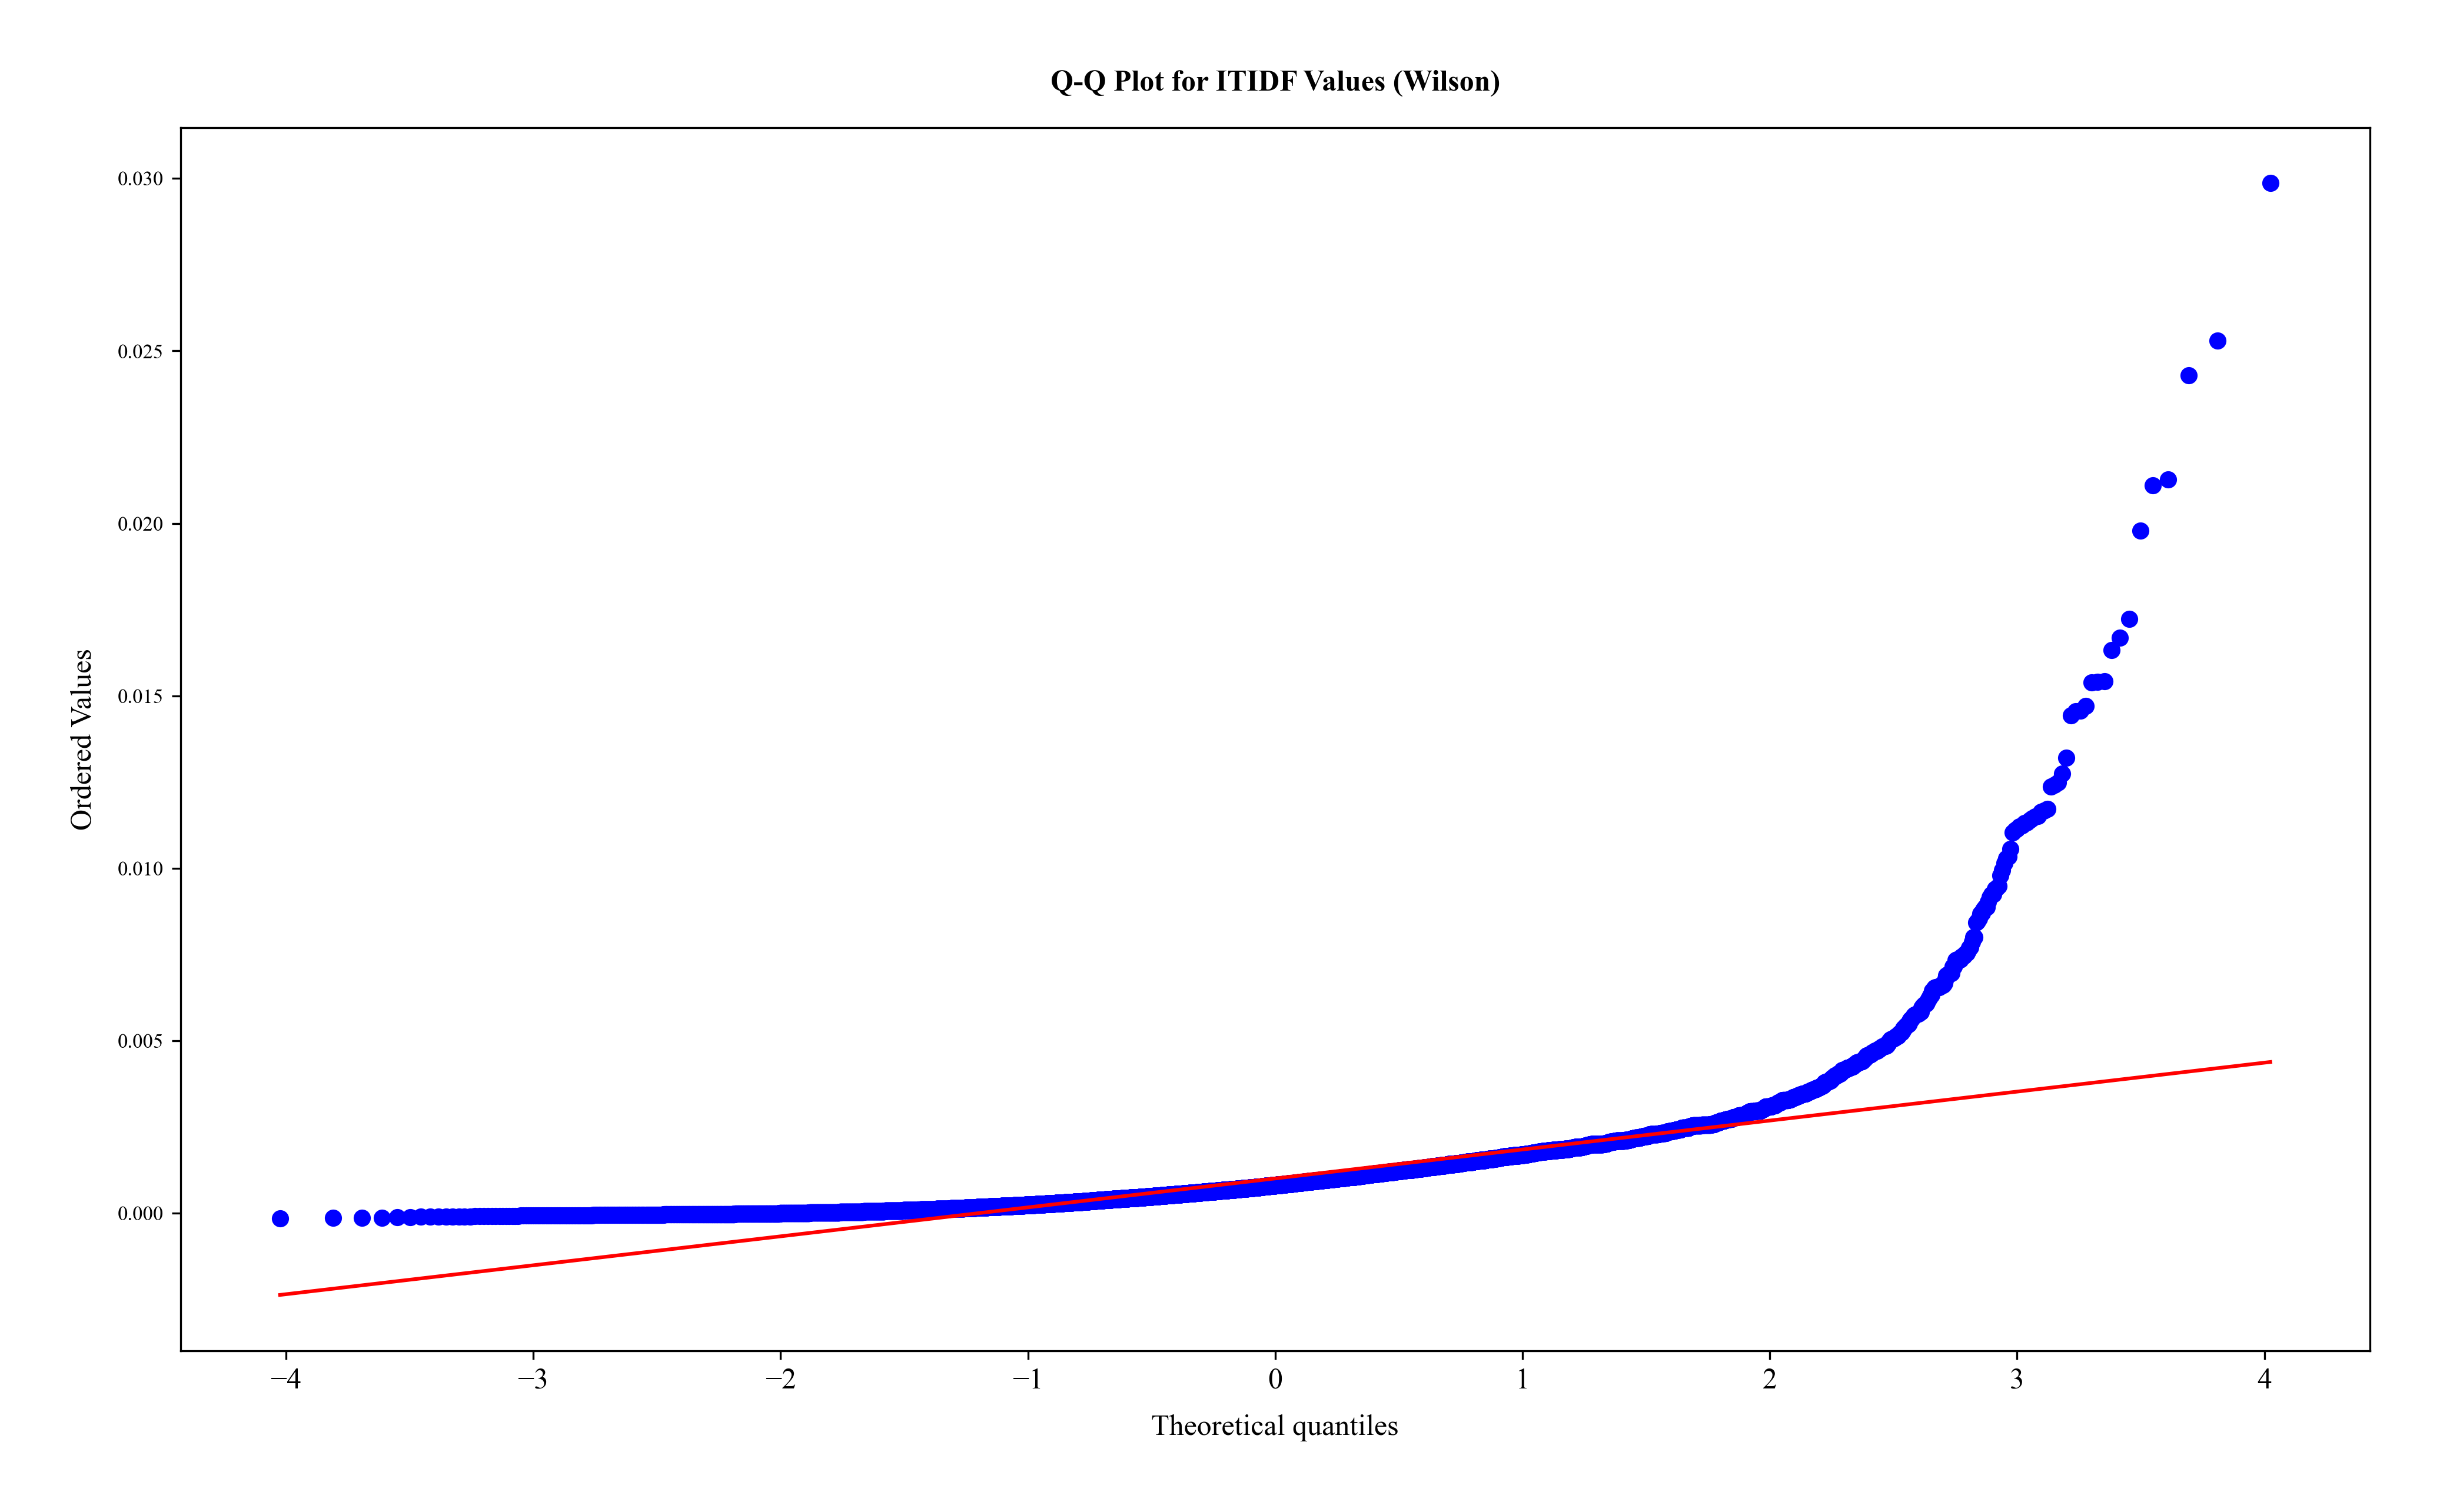

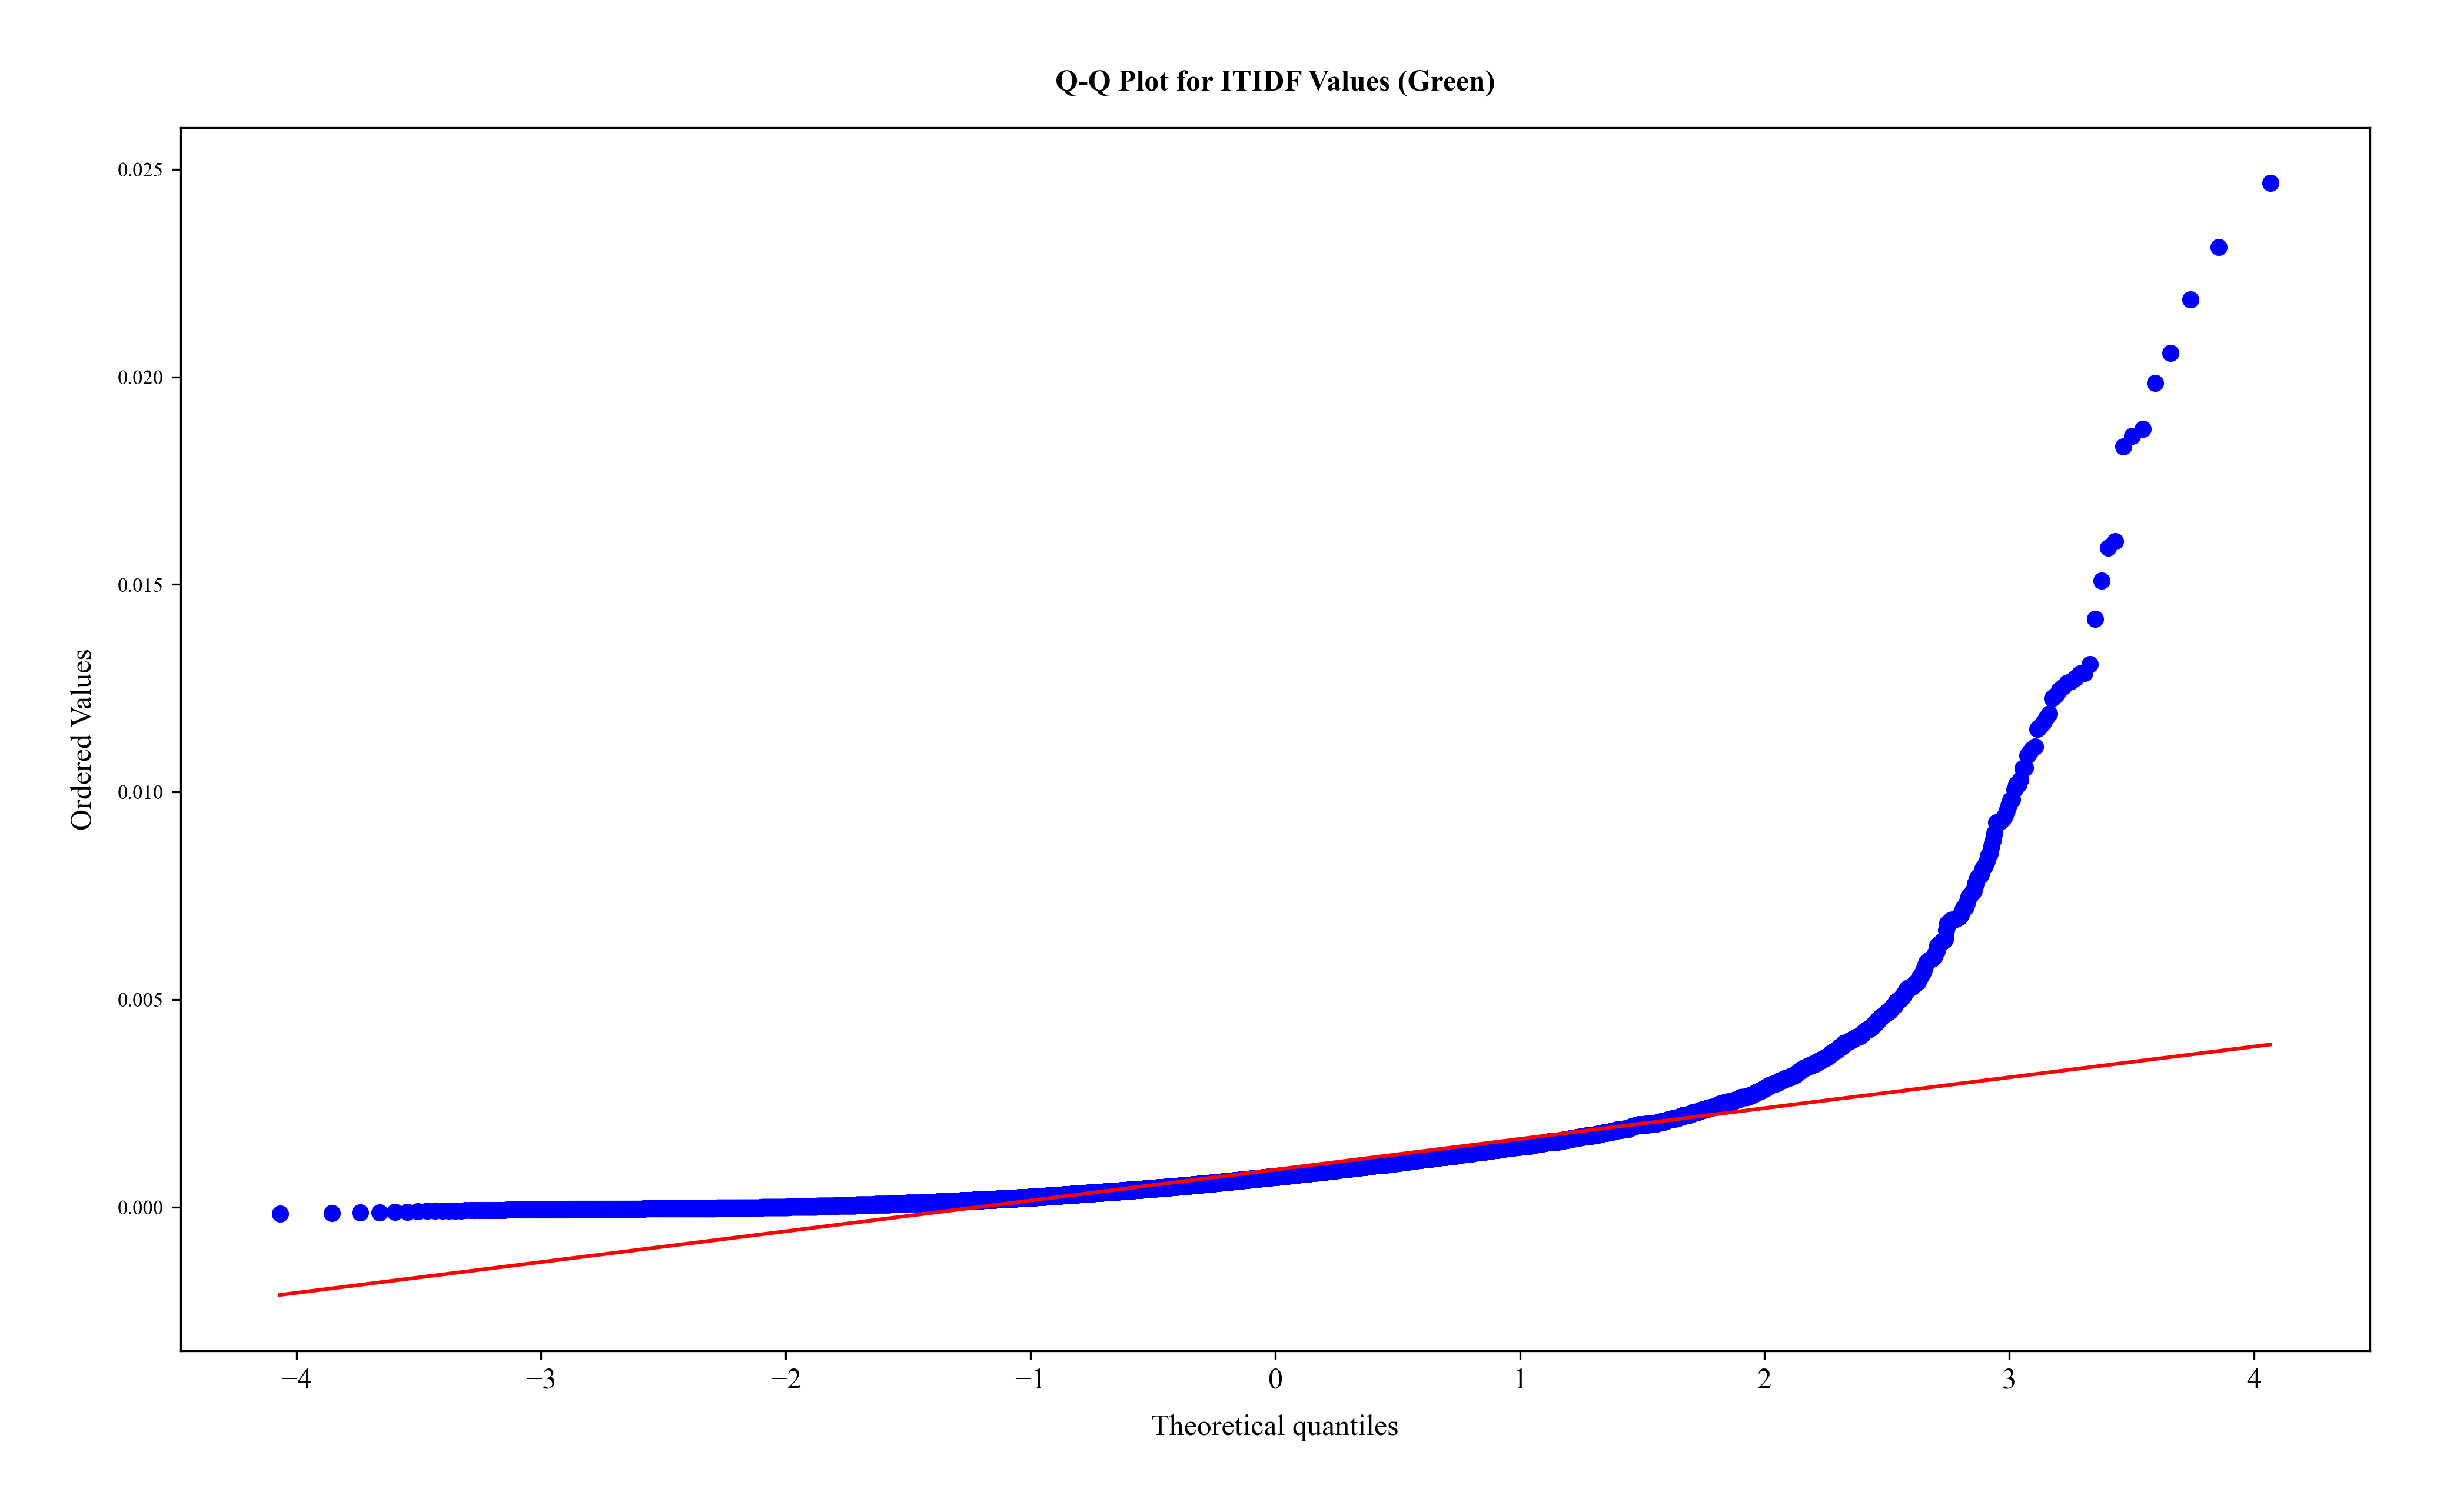

In [8]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

def plot_qq(itidf, translator="X"):
    """
    Create a Q-Q plot for the ITIDF values.
    
    Parameters:
    -----------
    itidf : list
        List of ITIDF values to plot
    """
    stats.probplot(itidf, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot for ITIDF Values ({translator})")
    plt.show()

# Extract unique translators
unique_translators = tfidf_df["translator"].unique()

# Loop through each translator and extract ITIDF values
for translator in translators:
    subset = tfidf_df[tfidf_df["translator"] == translator]
    
    # Extract ITIDF values from the dictionary column
    itidf_values = [value for tfidf_dict in subset["tf_idf"]\
                          for value in tfidf_dict.values()]
    
    # Plot the Q-Q plot for the translator
    if itidf_values:  # Ensure it's not empty
        plot_qq(itidf_values, translator)


The data seems to be not normally distributed, as the Q-Q plot deviates from the diagonal line.
Shapiro confirms this story, however, the data is too large for Shapiro test.

In [9]:
for translator in translators:
    subset = tfidf_df[tfidf_df["translator"] == translator]
    
    # Extract ITIDF values
    itidf_values = [value for tfidf_dict in subset["tf_idf"] for value in tfidf_dict.values()]
    
    print(f"Translator: {translator}, Sample Size: {len(itidf_values)}")

    if len(itidf_values) > 5000:
        print(f"Skipping Shapiro-Wilk test for {translator} (Sample too large)")
        continue  # Skip large samples
    
    if itidf_values:  # Ensure it's not empty
        shapiro_test(itidf_values)

Translator: AT_Murray, Sample Size: 23618
Skipping Shapiro-Wilk test for AT_Murray (Sample too large)
Translator: Fitzgerald, Sample Size: 28652
Skipping Shapiro-Wilk test for Fitzgerald (Sample too large)
Translator: Lattimore, Sample Size: 26839
Skipping Shapiro-Wilk test for Lattimore (Sample too large)
Translator: Fagles, Sample Size: 31408
Skipping Shapiro-Wilk test for Fagles (Sample too large)
Translator: Wilson, Sample Size: 24233
Skipping Shapiro-Wilk test for Wilson (Sample too large)
Translator: Green, Sample Size: 29098
Skipping Shapiro-Wilk test for Green (Sample too large)


In [10]:
from scipy.stats import shapiro
# Shapiro test for normality
def shapiro_test(data):
    """"
    Perform the Shapiro-Wilk test for normality from scipy.stats and print the results.

    Parameters:
    -----------
    data : list or array
        The data to be tested for normality.

    Returns: shapiro statistic and p-value

    """        
    stat, p = shapiro(data)
    print(f"Shapiro-Wilk Test: p-value = {p}")
    print(f"Shapiro-Wilk Test: statistic = {stat}")
    if p > 0.05:
        print("Data appears to be normally distributed (fail to reject H0).")
    else:
        print("Data is not normally distributed (reject H0).")
    return stat, p

# Loop through each translator and extract ITIDF values
for translator in translators:
    subset = tfidf_df[tfidf_df["translator"] == translator]
    
    # Extract ITIDF values from the dictionary column
    itidf_values = [value for tfidf_dict in subset["tf_idf"]\
                          for value in tfidf_dict.values()]
    
    # Perform the Shapiro-Wilk test for normality
    if itidf_values:  # Ensure it's not empty
        shapiro_test(itidf_values)


Shapiro-Wilk Test: p-value = 0.0
Shapiro-Wilk Test: statistic = 0.640259325504303
Data is not normally distributed (reject H0).
Shapiro-Wilk Test: p-value = 0.0
Shapiro-Wilk Test: statistic = 0.7373599410057068
Data is not normally distributed (reject H0).
Shapiro-Wilk Test: p-value = 0.0
Shapiro-Wilk Test: statistic = 0.619519829750061
Data is not normally distributed (reject H0).
Shapiro-Wilk Test: p-value = 0.0
Shapiro-Wilk Test: statistic = 0.6984273195266724
Data is not normally distributed (reject H0).
Shapiro-Wilk Test: p-value = 0.0
Shapiro-Wilk Test: statistic = 0.6707950234413147
Data is not normally distributed (reject H0).
Shapiro-Wilk Test: p-value = 0.0
Shapiro-Wilk Test: statistic = 0.6523206233978271
Data is not normally distributed (reject H0).


In [11]:
from scipy.stats import kstest
from scipy.stats import anderson

# Kolmogorov-Smirnov test for normality
def KS_test(data):
    """"
    Perform the Kolmogorov-Smirnov test for normality from scipy.stats and print the results.

    Parameters:
    -----------
    data : list or array
        The data to be tested for normality.

    Returns: Ks statistic and p-value

    """        
    stat, p = kstest(itidf_values, 'norm')
    print(f"Kolmogorov-Smirnov Test: p-value = {p}")
    print(f"Kolmogorov-Smirnov Test: statistic = {stat}")
    if p > 0.05:
        print("Data appears to be normally distributed (fail to reject H0).")
    else:
        print("Data is not normally distributed (reject H0).")
    return stat, p

# Loop through each translator and extract ITIDF values
for translator in translators:
    subset = tfidf_df[tfidf_df["translator"] == translator]
    
    # Extract ITIDF values from the dictionary column
    itidf_values = [value for tfidf_dict in subset["tf_idf"]\
                          for value in tfidf_dict.values()]
    
    # Perform the Kolmogorov-Smirnov test for normality
    if itidf_values:  # Ensure it's not empty
        KS_test(itidf_values)

def AD_test(data):
    """
    Perform the Anderson-Darling test for normality from scipy.stats and print the results.
    
    Parameters:
    -----------
    data : list or array
        The data to be tested for normality.
    
    Returns: Anderson-Darling statistic and critical values
    """        
    result = anderson(data, dist='norm')
    print(f"Anderson-Darling Test: Statistic = {result.statistic}")
    
    for i, critical in enumerate(result.critical_values):
        significance_level = result.significance_level[i]
        print(f"Critical Value ({significance_level}%): {critical}")
    
    if result.statistic < result.critical_values[2]:  # Typically using the 5% level
        print("Data appears to be normally distributed (fail to reject H0).")
    else:
        print("Data is not normally distributed (reject H0).")
    
    return result.statistic, result.critical_values

# Loop through each translator and extract ITIDF values
for translator in translators:
    subset = tfidf_df[tfidf_df["translator"] == translator]
    
    # Extract ITIDF values from the dictionary column
    itidf_values = [value for tfidf_dict in subset["tf_idf"] for value in tfidf_dict.values()]
    
    # Perform the Anderson-Darling test for normality
    if itidf_values:  # Ensure it's not empty
        AD_test(itidf_values)


Kolmogorov-Smirnov Test: p-value = 0.0
Kolmogorov-Smirnov Test: statistic = 0.49992357969410645
Data is not normally distributed (reject H0).
Kolmogorov-Smirnov Test: p-value = 0.0
Kolmogorov-Smirnov Test: statistic = 0.49995160082577006
Data is not normally distributed (reject H0).
Kolmogorov-Smirnov Test: p-value = 0.0
Kolmogorov-Smirnov Test: statistic = 0.4999331533737007
Data is not normally distributed (reject H0).
Kolmogorov-Smirnov Test: p-value = 0.0
Kolmogorov-Smirnov Test: statistic = 0.4999435444759511
Data is not normally distributed (reject H0).
Kolmogorov-Smirnov Test: p-value = 0.0
Kolmogorov-Smirnov Test: statistic = 0.4999408085737283
Data is not normally distributed (reject H0).
Kolmogorov-Smirnov Test: p-value = 0.0
Kolmogorov-Smirnov Test: statistic = 0.49993634911266654
Data is not normally distributed (reject H0).
Anderson-Darling Test: Statistic = 1131.566517047835
Critical Value (15.0%): 0.576
Critical Value (10.0%): 0.656
Critical Value (5.0%): 0.787
Critical 

In [12]:
from scipy.stats import mannwhitneyu


def mannwhitneyu_test(x, y, alternative='two-sided'):
    """
    Perform the Mann-Whitney U test for comparing two independent samples.
    """
    stat, p = mannwhitneyu(x, y, alternative=alternative)
    
    print(f"Mann-Whitney U test statistic: {stat}, p-value: {p}")

    if p < 0.05:
        print("[ø] Reject H₀: The distributions of the translations are significantly different.")
    else:
        print("[X] Fail to reject H₀: No significant difference between the translations.")

# Loop through each pair of translators and compare their ITIDF values
unique_translators = tfidf_df["translator"].unique()

for i, translator_1 in enumerate(unique_translators):
    for translator_2 in unique_translators[i+1:]:  # Avoid duplicate comparisons
        subset_1 = tfidf_df[tfidf_df["translator"] == translator_1]
        subset_2 = tfidf_df[tfidf_df["translator"] == translator_2]
        
        # Extract ITIDF values
        itidf_1 = [value for tfidf_dict in subset_1["tf_idf"] for value in tfidf_dict.values()]
        itidf_2 = [value for tfidf_dict in subset_2["tf_idf"] for value in tfidf_dict.values()]
        
        # Perform the Mann-Whitney U test if both sets have values
        if itidf_1 and itidf_2:
            print(f"\nComparing {translator_1} vs. {translator_2}:")
            mannwhitneyu_test(itidf_1, itidf_2)


Comparing AT_Murray vs. Fitzgerald:
Mann-Whitney U test statistic: 327514433.5, p-value: 2.753312745775185e-10
[ø] Reject H₀: The distributions of the translations are significantly different.

Comparing AT_Murray vs. Lattimore:
Mann-Whitney U test statistic: 344093712.5, p-value: 4.1460629637998725e-62
[ø] Reject H₀: The distributions of the translations are significantly different.

Comparing AT_Murray vs. Fagles:
Mann-Whitney U test statistic: 384530414.5, p-value: 1.446105131566514e-13
[ø] Reject H₀: The distributions of the translations are significantly different.

Comparing AT_Murray vs. Wilson:
Mann-Whitney U test statistic: 275920916.5, p-value: 1.1805527805487168e-11
[ø] Reject H₀: The distributions of the translations are significantly different.

Comparing AT_Murray vs. Green:
Mann-Whitney U test statistic: 354107096.0, p-value: 1.5744750350832475e-09
[ø] Reject H₀: The distributions of the translations are significantly different.

Comparing Fitzgerald vs. Lattimore:
Mann

The only translations with **similar TFIDF distribution** are
- **Fagles vs. Green**
    * Mann-Whitney U test statistic: 454471214.0, p-value: 0.24725553375036124  
    * [X] Fail to reject H₀: No significant difference between the translations.

- **Wilson vs. Fitzgerald**
    * Mann-Whitney U test statistic: 345432254.5, p-value: 0.32275841506245295  
    * [X] Fail to reject H₀: No significant difference between the translations.